# Project 2: Data Cleaning and Missing Value Strategy

## Learning objective

Missing values are not only a preprocessing inconvenience. They can affect statistical conclusions, model training, evaluation, and interpretation. This project studies missing values using the Titanic dataset and compares several imputation strategies through downstream classification performance.

The workflow is:

1. inspect missingness patterns,
2. discuss possible missing-data mechanisms,
3. prevent leakage using train/test split and pipelines,
4. compare dropping rows, simple imputation, missing indicators, KNN imputation, and iterative imputation,
5. evaluate how cleaning choices affect classification metrics,
6. interpret errors and missingness as a possible source of information.


## Prerequisites

The notebook assumes basic knowledge of pandas, NumPy, visualization, train/test splitting, classification metrics, and scikit-learn pipelines.


## Problem statement

Given a dataset with missing values, design and compare different cleaning and imputation strategies, then evaluate how these strategies affect downstream prediction performance.

The target is passenger survival. The modeling objective is not to build the best possible Titanic classifier, but to understand how missing-value decisions influence model behavior.


## Dataset description and source

The project uses the Titanic dataset available through `seaborn.load_dataset("titanic")`, so no manually downloaded Kaggle file is required.

Important columns:

| Column | Meaning |
|---|---|
| `survived` | Target variable: 1 if survived, 0 otherwise. |
| `pclass` | Passenger class. |
| `sex` | Passenger sex. |
| `age` | Passenger age. Contains missing values. |
| `sibsp` | Number of siblings/spouses aboard. |
| `parch` | Number of parents/children aboard. |
| `fare` | Ticket fare. |
| `embarked` | Port of embarkation. Contains a few missing values. |
| `class` | Passenger class as a category; redundant with `pclass`. |
| `who` | Passenger category such as man, woman, child. Derived from sex/age. |
| `adult_male` | Derived demographic indicator. |
| `deck` | Cabin deck. Highly missing. |
| `embark_town` | Embarkation town; related to `embarked`. |
| `alive` | Text version of survival; direct leakage and must be removed. |
| `alone` | Whether the passenger travelled alone. |

Leakage warning: `alive` directly duplicates the target and should never be used as a predictor.


In [ ]:
# Optional installation cell. Uncomment if running in a fresh environment.
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy


## Load required libraries

Pipelines and column transformers are used so that imputation is learned only from training data. This avoids train-test leakage.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## Load dataset directly

The dataset is loaded through seaborn. The first inspection checks shape, column types, and summary statistics.


In [2]:
df = sns.load_dataset("titanic")
print("Shape:", df.shape)
display(df.head())

display(df.info())
display(df.describe(include="all"))


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000,891.000,891,714.000,891.000,891.000,891.000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.384,2.309,NaN,29.699,0.523,0.382,32.204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.487,0.836,NaN,14.526,1.103,0.806,49.693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000,1.000,NaN,0.420,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000,2.000,NaN,20.125,0.000,0.000,7.910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000,3.000,NaN,28.000,0.000,0.000,14.454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000,3.000,NaN,38.000,1.000,0.000,31.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial data understanding

Before handling missing values, inspect the target distribution and simple relationships between survival and selected variables. These summaries also help detect leakage or redundant columns.


Target distribution:


0   0.616
1   0.384
Name: proportion, dtype: float64

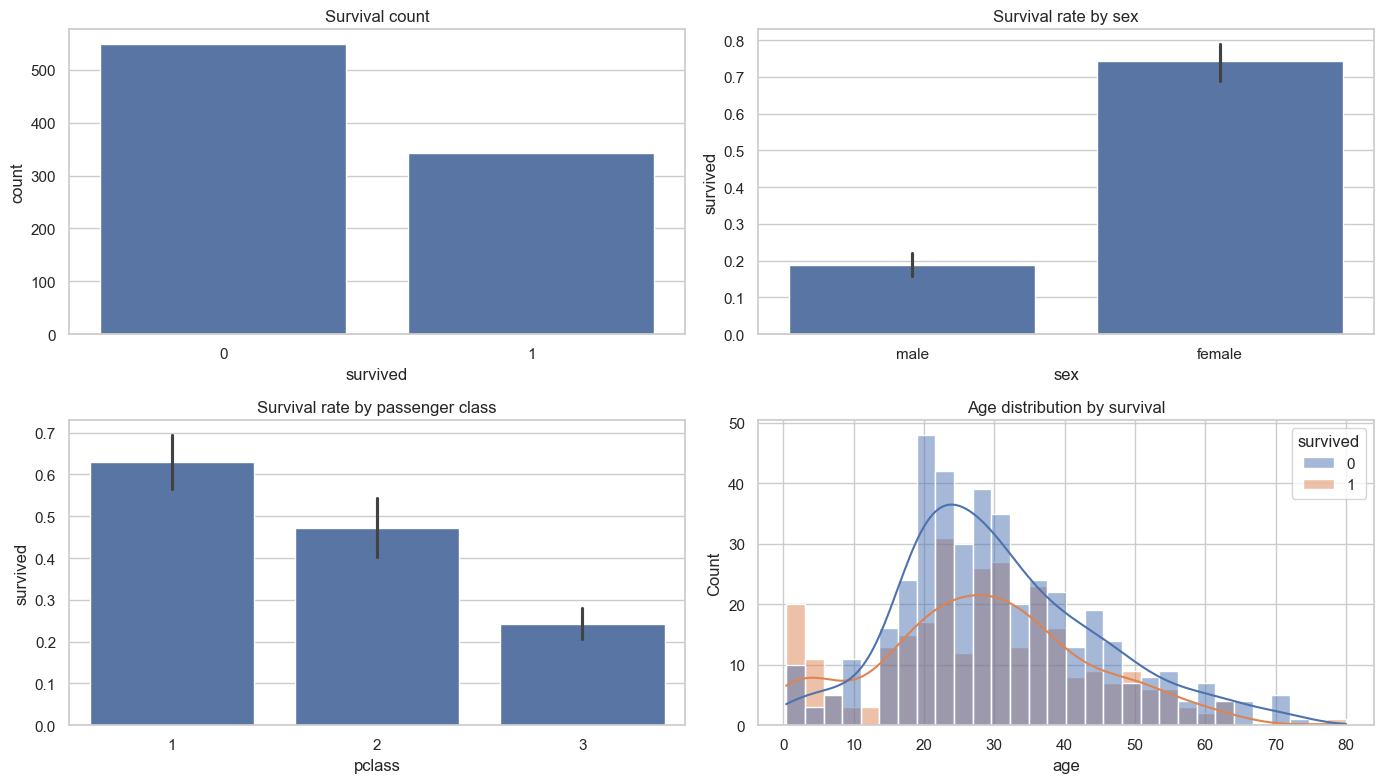


Counts for sex:


male      577
female    314
Name: sex, dtype: int64


Counts for pclass:


3    491
1    216
2    184
Name: pclass, dtype: int64


Counts for embarked:


S      644
C      168
Q       77
NaN      2
Name: embarked, dtype: int64


Counts for alone:


True     537
False    354
Name: alone, dtype: int64


Counts for deck:


NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: deck, dtype: int64

In [3]:
print("Target distribution:")
display(df["survived"].value_counts(normalize=True).rename("proportion"))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.countplot(data=df, x="survived", ax=axes[0, 0])
axes[0, 0].set_title("Survival count")
sns.barplot(data=df, x="sex", y="survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival rate by sex")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1, 0])
axes[1, 0].set_title("Survival rate by passenger class")
sns.histplot(data=df, x="age", hue="survived", kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Age distribution by survival")
plt.tight_layout()
plt.show()

categorical_cols_to_check = ["sex", "pclass", "embarked", "alone", "deck"]
for col in categorical_cols_to_check:
    print(f"\nCounts for {col}:")
    display(df[col].value_counts(dropna=False).head(10))


### Interpretation guide

Check whether the target is heavily imbalanced and whether survival rates differ across major groups. These patterns provide context for later model errors, but they should not be interpreted causally without additional assumptions.


## Missing value inspection

Missingness is inspected by count, percentage, heatmap, and relationship with key groups. The goal is to identify whether missingness may itself contain information.


,missing_count,missing_percent
deck,688,77.217
age,177,19.865
embarked,2,0.224
embark_town,2,0.224
survived,0,0.000
pclass,0,0.000
sex,0,0.000
sibsp,0,0.000
parch,0,0.000
fare,0,0.000


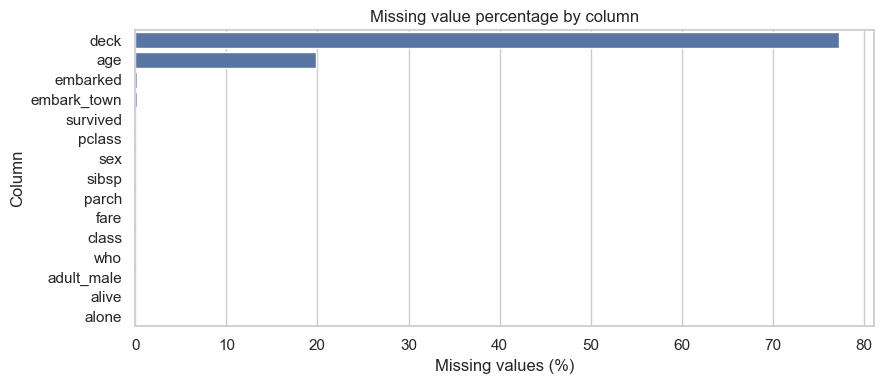

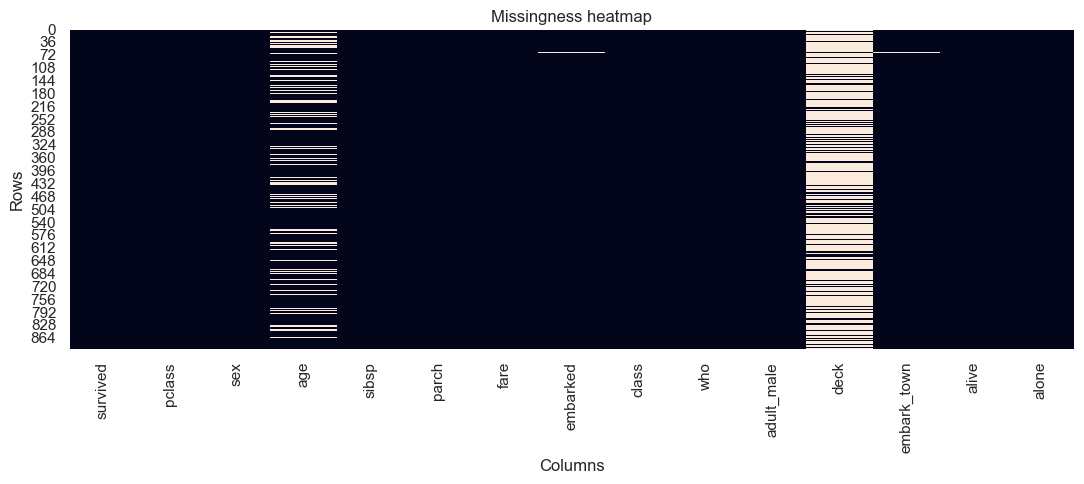

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)
display(missing)

plt.figure(figsize=(9, 4))
sns.barplot(data=missing.reset_index(), x="missing_percent", y="index")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missing value percentage by column")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missingness heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


age_missing  deck_missing  embarked_missing
survived pclass                                             
0        1             0.200         0.275             0.000
         2             0.072         0.969             0.000
         3             0.274         0.984             0.000
1        1             0.103         0.140             0.015
         2             0.046         0.851             0.000
         3             0.286         0.950             0.000

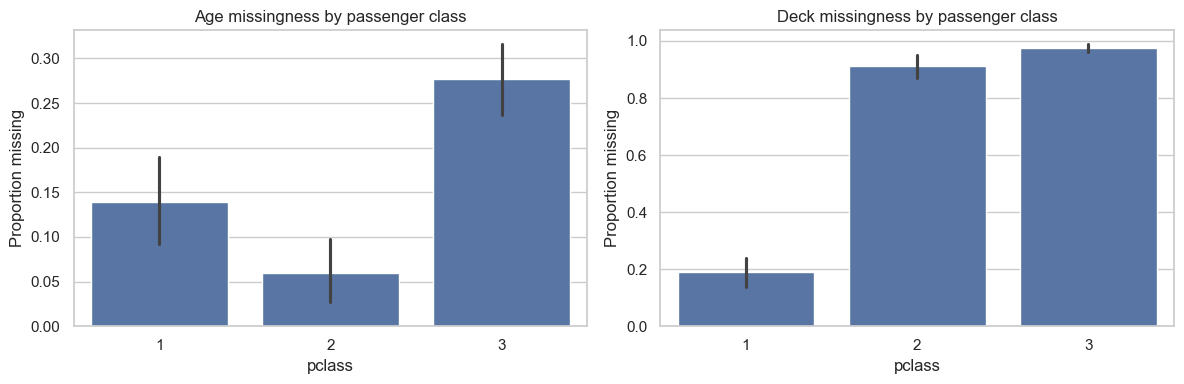

In [5]:
# Missingness by target and passenger class.
missing_by_group = df.assign(
    age_missing=df["age"].isna().astype(int),
    deck_missing=df["deck"].isna().astype(int),
    embarked_missing=df["embarked"].isna().astype(int)
).groupby(["survived", "pclass"])[["age_missing", "deck_missing", "embarked_missing"]].mean()

display(missing_by_group)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df.assign(age_missing=df["age"].isna()), x="pclass", y="age_missing", ax=axes[0])
axes[0].set_title("Age missingness by passenger class")
axes[0].set_ylabel("Proportion missing")
sns.barplot(data=df.assign(deck_missing=df["deck"].isna()), x="pclass", y="deck_missing", ax=axes[1])
axes[1].set_title("Deck missingness by passenger class")
axes[1].set_ylabel("Proportion missing")
plt.tight_layout()
plt.show()


### Interpretation guide

After running the cells, check whether `age`, `deck`, and `embarked` have different missingness severity. Compare missingness across survival and class groups. If missingness rates vary by group, missing values are unlikely to be completely random with respect to observed variables.


## Missing data mechanisms

Three common mechanisms are useful for reasoning:

- **MCAR: Missing Completely At Random**. Missingness is unrelated to observed and unobserved data. Example: a random data-entry failure.
- **MAR: Missing At Random**. Missingness depends on observed variables. Example: age missingness may differ by passenger class.
- **MNAR: Missing Not At Random**. Missingness depends on the missing value itself or an unobserved factor. Example: cabin information may be missing because records were not collected for certain kinds of passengers.

For Titanic, the mechanism cannot be proven from the observed table alone. The notebook investigates evidence, but avoids claiming certainty.


## Data leakage discussion

Two leakage issues are important here:

1. **Target leakage through columns**: `alive` directly duplicates `survived`, so it must be removed.
2. **Preprocessing leakage**: imputation values must be learned from the training data only. If the full dataset is imputed before the split, test-set information enters the training process.

Scikit-learn `Pipeline` and `ColumnTransformer` avoid this leakage because imputation is fitted only inside the training fold/data and then applied to the test data.


## Define features and target

A compact feature set is used to keep the comparison focused on missing-value strategy:

- Numerical: `pclass`, `age`, `sibsp`, `parch`, `fare`
- Categorical: `sex`, `embarked`, `alone`

Highly redundant or leakage-prone columns such as `alive`, `class`, `who`, `adult_male`, and `embark_town` are excluded. The high-missingness `deck` column is studied separately rather than included in the main feature set.


In [6]:
target = "survived"
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked", "alone"]
feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training target distribution:")
display(y_train.value_counts(normalize=True))
print("Test target distribution:")
display(y_test.value_counts(normalize=True))


Training shape: (668, 8)
Test shape: (223, 8)
Training target distribution:


0   0.617
1   0.383
Name: survived, dtype: float64

Test target distribution:


0   0.614
1   0.386
Name: survived, dtype: float64

## Evaluation helper functions

All strategies are evaluated using the same metrics. Accuracy is reported, but F1-score, recall, precision, and ROC-AUC are also important because classification decisions may have different types of errors.


In [7]:
results = []
fitted_models = {}

def evaluate_predictions(strategy_name, y_true, y_pred, y_prob, train_samples_used, test_samples_used):
    metrics = {
        "strategy": strategy_name,
        "train_samples_used": train_samples_used,
        "test_samples_evaluated": test_samples_used,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }
    results.append(metrics)
    return metrics

def fit_and_evaluate(strategy_name, pipeline, X_train_data=X_train, y_train_data=y_train, X_test_data=X_test, y_test_data=y_test):
    pipeline.fit(X_train_data, y_train_data)
    y_pred = pipeline.predict(X_test_data)
    y_prob = pipeline.predict_proba(X_test_data)[:, 1] if hasattr(pipeline, "predict_proba") else None
    metrics = evaluate_predictions(strategy_name, y_test_data, y_pred, y_prob, len(X_train_data), len(X_test_data))
    fitted_models[strategy_name] = pipeline
    display(pd.DataFrame([metrics]))
    print(classification_report(y_test_data, y_pred, zero_division=0))
    return pipeline


## Baseline: drop rows with missing values

Dropping rows is simple and sometimes acceptable when missingness is tiny. It can be harmful when missingness is large or systematic because it reduces sample size and may change the population being modeled.

The baseline is evaluated on test rows that also have complete values, so its metrics are not perfectly comparable with models evaluated on the full test set. The reduced sample count is reported explicitly.


In [8]:
complete_train_mask = X_train.notna().all(axis=1)
complete_test_mask = X_test.notna().all(axis=1)

X_train_drop = X_train.loc[complete_train_mask]
y_train_drop = y_train.loc[complete_train_mask]
X_test_drop = X_test.loc[complete_test_mask]
y_test_drop = y_test.loc[complete_test_mask]

print("Training samples before dropping:", len(X_train))
print("Training samples after dropping:", len(X_train_drop))
print("Test samples before dropping:", len(X_test))
print("Test samples after dropping:", len(X_test_drop))

preprocess_drop = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe_drop = Pipeline(steps=[
    ("preprocess", preprocess_drop),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

fit_and_evaluate("drop_missing_rows_logistic", pipe_drop, X_train_drop, y_train_drop, X_test_drop, y_test_drop)


Training samples before dropping: 668
Training samples after dropping: 535
Test samples before dropping: 223
Test samples after dropping: 177


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,drop_missing_rows_logistic,535,177,0.791,0.726,0.757,0.741,0.856


              precision    recall  f1-score   support

           0       0.84      0.81      0.82       107
           1       0.73      0.76      0.74        70

    accuracy                           0.79       177
   macro avg       0.78      0.79      0.78       177
weighted avg       0.79      0.79      0.79       177



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Interpretation guide

Compare the number of retained samples with the original train/test sizes. If many rows are removed, the baseline may be biased toward passengers with more complete records.


## Strategy 1: simple imputation

Numerical variables are imputed using the median, which is robust to skewed values. Categorical variables are imputed using the most frequent category. The model is logistic regression because it is interpretable and provides probabilities.


In [9]:
numeric_simple = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_simple = ColumnTransformer(
    transformers=[
        ("num", numeric_simple, numeric_features),
        ("cat", categorical_simple, categorical_features)
    ]
)

pipe_simple = Pipeline(steps=[
    ("preprocess", preprocess_simple),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

fit_and_evaluate("simple_imputation_logistic", pipe_simple)


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,simple_imputation_logistic,668,223,0.785,0.732,0.698,0.714,0.847


              precision    recall  f1-score   support

           0       0.82      0.84      0.83       137
           1       0.73      0.70      0.71        86

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## Strategy 2: simple imputation with missing indicators

A missing indicator allows the model to learn whether the fact that a value was missing is predictive. This is especially useful when missingness is related to observed groups or outcomes.


In [10]:
numeric_indicator = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

preprocess_indicator = ColumnTransformer(
    transformers=[
        ("num", numeric_indicator, numeric_features),
        ("cat", categorical_simple, categorical_features)
    ]
)

pipe_indicator = Pipeline(steps=[
    ("preprocess", preprocess_indicator),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

fit_and_evaluate("simple_imputation_with_indicators_logistic", pipe_indicator)


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,simple_imputation_with_indicators_logistic,668,223,0.780,0.734,0.674,0.703,0.843


              precision    recall  f1-score   support

           0       0.81      0.85      0.83       137
           1       0.73      0.67      0.70        86

    accuracy                           0.78       223
   macro avg       0.77      0.76      0.76       223
weighted avg       0.78      0.78      0.78       223



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## Strategy 3: KNN imputation

KNN imputation fills missing numerical values using nearby samples. It can capture local similarity, but it is sensitive to feature scaling, distance definition, and noise. It does not automatically guarantee better prediction.


In [11]:
numeric_knn = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ("scaler", StandardScaler())
])

preprocess_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_knn, numeric_features),
        ("cat", categorical_simple, categorical_features)
    ]
)

pipe_knn = Pipeline(steps=[
    ("preprocess", preprocess_knn),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

fit_and_evaluate("knn_imputation_logistic", pipe_knn)


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,knn_imputation_logistic,668,223,0.794,0.733,0.733,0.733,0.847


              precision    recall  f1-score   support

           0       0.83      0.83      0.83       137
           1       0.73      0.73      0.73        86

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(weights='distance')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## Strategy 4: iterative/model-based imputation

Iterative imputation models each incomplete numerical feature as a function of other features. It can be useful when variables have meaningful relationships, but it also adds modeling assumptions.


In [12]:
numeric_iterative = Pipeline(steps=[
    ("imputer", IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        random_state=RANDOM_STATE,
        sample_posterior=False
    )),
    ("scaler", StandardScaler())
])

preprocess_iterative = ColumnTransformer(
    transformers=[
        ("num", numeric_iterative, numeric_features),
        ("cat", categorical_simple, categorical_features)
    ]
)

pipe_iterative = Pipeline(steps=[
    ("preprocess", preprocess_iterative),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

fit_and_evaluate("iterative_imputation_logistic", pipe_iterative)


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,iterative_imputation_logistic,668,223,0.798,0.741,0.733,0.737,0.847


              precision    recall  f1-score   support

           0       0.83      0.84      0.84       137
           1       0.74      0.73      0.74        86

    accuracy                           0.80       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(estimator=BayesianRidge(),
                                                                                    max_iter=20,
                                                                                    random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## Strategy 5: tree-based model with simple imputation

A random forest is added as a nonlinear comparison. Tree models can capture interactions between variables, but they still require a valid missing-value strategy when using scikit-learn's `RandomForestClassifier`.


In [13]:
pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess_simple),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        min_samples_leaf=3
    ))
])

fit_and_evaluate("simple_imputation_random_forest", pipe_rf)


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,simple_imputation_random_forest,668,223,0.794,0.756,0.686,0.720,0.835


              precision    recall  f1-score   support

           0       0.81      0.86      0.84       137
           1       0.76      0.69      0.72        86

    accuracy                           0.79       223
   macro avg       0.79      0.77      0.78       223
weighted avg       0.79      0.79      0.79       223



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=3, n_estimators=300,
                                        random_state=42))])

## Compare all strategies

The comparison table reports predictive performance and the number of samples used. The drop-missing baseline should be interpreted carefully because it may evaluate on a smaller test subset.


,strategy,train_samples_used,test_samples_evaluated,accuracy,precision,recall,f1,roc_auc
0,drop_missing_rows_logistic,535,177,0.791,0.726,0.757,0.741,0.856
4,iterative_imputation_logistic,668,223,0.798,0.741,0.733,0.737,0.847
3,knn_imputation_logistic,668,223,0.794,0.733,0.733,0.733,0.847
5,simple_imputation_random_forest,668,223,0.794,0.756,0.686,0.720,0.835
1,simple_imputation_logistic,668,223,0.785,0.732,0.698,0.714,0.847
2,simple_imputation_with_indicators_logistic,668,223,0.780,0.734,0.674,0.703,0.843


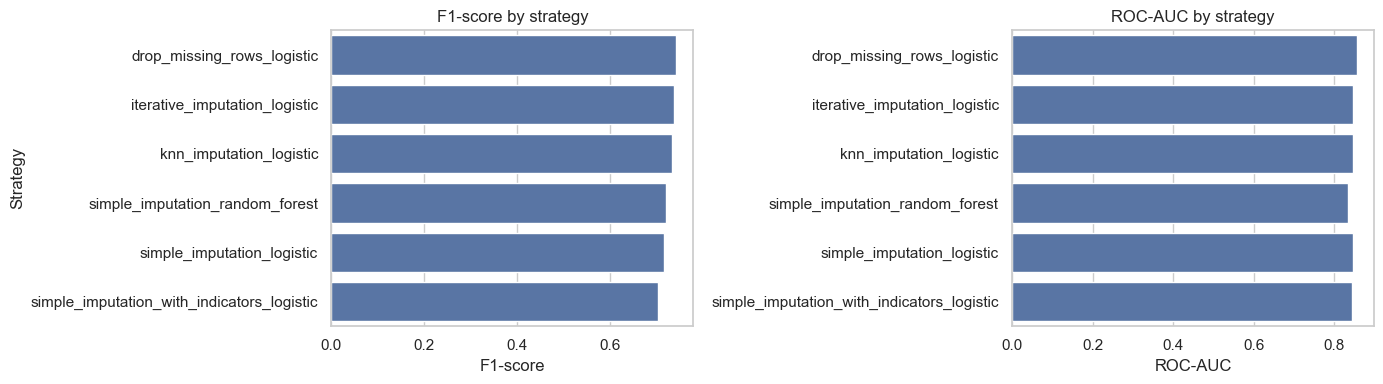

Best strategy by F1-score: drop_missing_rows_logistic


In [14]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=results_df, x="f1", y="strategy", ax=axes[0])
axes[0].set_title("F1-score by strategy")
axes[0].set_xlabel("F1-score")
axes[0].set_ylabel("Strategy")

sns.barplot(data=results_df, x="roc_auc", y="strategy", ax=axes[1])
axes[1].set_title("ROC-AUC by strategy")
axes[1].set_xlabel("ROC-AUC")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

best_strategy_name = results_df.iloc[0]["strategy"]
print("Best strategy by F1-score:", best_strategy_name)


### Interpretation guide

After execution, compare whether missing indicators improved performance, whether KNN or iterative imputation helped, and whether the random forest changed the trade-off between recall and precision. A small metric difference should not be over-interpreted without cross-validation or repeated experiments.


## Coefficient or feature-importance interpretation

Model interpretation depends on the preprocessing pipeline. One-hot encoding expands categorical variables, and scaling changes the numerical coefficient scale. Coefficients and feature importances describe model behavior, not causal effects.


,feature,coefficient
6,sex_male,-1.274
0,pclass,-0.896
1,age,-0.517
2,sibsp,-0.407
9,embarked_S,-0.313
11,alone_True,-0.279
3,parch,-0.132
7,embarked_C,-0.020
4,fare,0.115
10,alone_False,0.282


,feature,coefficient
1,age,-0.517
2,sibsp,-0.407
9,embarked_S,-0.313
11,alone_True,-0.279
3,parch,-0.132
7,embarked_C,-0.020
4,fare,0.115
10,alone_False,0.282
8,embarked_Q,0.336
5,sex_female,1.277


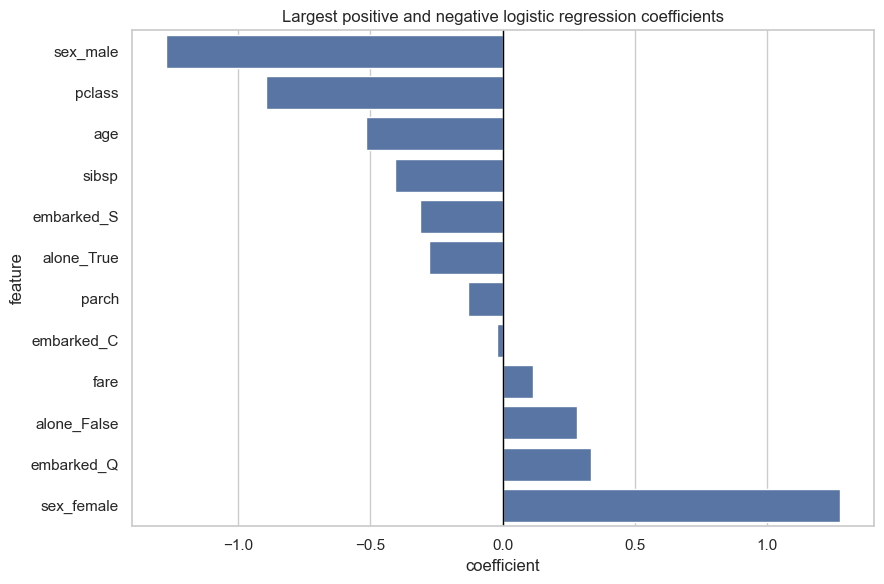

In [15]:
def get_feature_names_from_preprocessor(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder" and transformer == "drop":
            continue
        fitted_transformer = transformer
        if hasattr(fitted_transformer, "named_steps"):
            last_step = list(fitted_transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                try:
                    names.extend(last_step.get_feature_names_out(cols))
                except TypeError:
                    names.extend(last_step.get_feature_names_out())
            else:
                # Handle numerical imputer with indicators.
                output_count = fitted_transformer.transform(pd.DataFrame(np.zeros((1, len(cols))), columns=cols)).shape[1]
                if output_count == len(cols):
                    names.extend(cols)
                else:
                    names.extend(list(cols) + [f"{c}_missing_indicator" for c in cols][:output_count-len(cols)])
        elif hasattr(fitted_transformer, "get_feature_names_out"):
            names.extend(fitted_transformer.get_feature_names_out(cols))
        else:
            names.extend(cols)
    return np.array(names, dtype=object)

# Use the best fitted model if available. For a cleaner coefficient interpretation,
# the simple logistic model is usually easier to read.
interpret_model_name = "simple_imputation_logistic"
model_to_interpret = fitted_models[interpret_model_name]
preprocessor = model_to_interpret.named_steps["preprocess"]
feature_names = get_feature_names_from_preprocessor(preprocessor)
model = model_to_interpret.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

display(coef_df.head(10))
display(coef_df.tail(10))

plt.figure(figsize=(9, 6))
plot_coef = pd.concat([coef_df.head(8), coef_df.tail(8)])
sns.barplot(data=plot_coef, x="coefficient", y="feature")
plt.axvline(0, color="black", linewidth=1)
plt.title("Largest positive and negative logistic regression coefficients")
plt.tight_layout()
plt.show()


### Interpretation guide

Positive coefficients increase the model's log-odds for survival, while negative coefficients decrease it. Interpret them as associations learned by the model after preprocessing, not as causal claims about survival.


## Error analysis

Error analysis studies where the selected model fails. False positives and false negatives may have different meanings depending on the decision context.


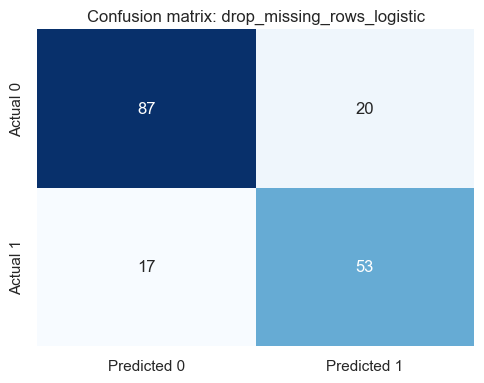

,count,mean_prob_survival,mean_age,mean_fare
error_type,,,,
correct,140,0.400,30.184,38.811
false_negative,17,0.257,28.706,20.849
false_positive,20,0.631,20.900,54.172


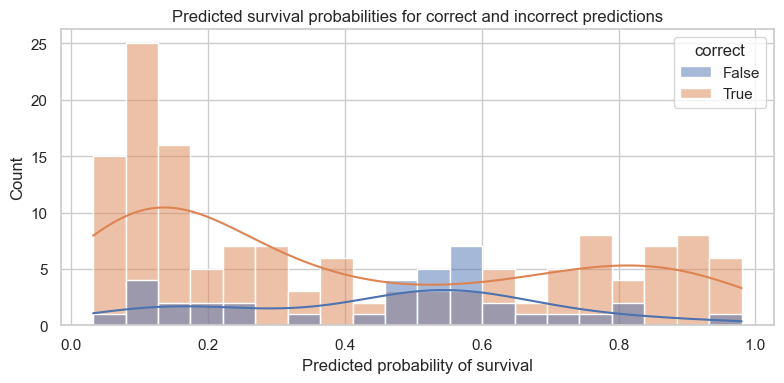

Confident wrong examples:


,pclass,age,sibsp,parch,fare,sex,embarked,alone,actual,predicted,prob_survival,correct,error_type,confidence
297,1,2.000,1,2,151.550,female,S,False,0,1,0.980,False,false_positive,0.980
570,2,62.000,0,0,10.500,male,S,True,1,0,0.074,False,false_negative,0.926
804,3,27.000,0,0,6.975,male,S,True,1,0,0.103,False,false_negative,0.897
146,3,27.000,0,0,7.796,male,S,True,1,0,0.103,False,false_negative,0.897
271,3,25.000,0,0,0.000,male,S,True,1,0,0.109,False,false_negative,0.891
455,3,29.000,0,0,7.896,male,C,True,1,0,0.112,False,false_negative,0.888
553,3,22.000,0,0,7.225,male,C,True,1,0,0.145,False,false_negative,0.855
204,3,18.000,0,0,8.050,male,S,True,1,0,0.146,False,false_negative,0.854
205,3,2.000,0,1,10.463,female,S,False,0,1,0.837,False,false_positive,0.837
199,2,24.000,0,0,13.000,female,S,True,0,1,0.828,False,false_positive,0.828


In [16]:
best_model = fitted_models[best_strategy_name]

# The drop-missing baseline was evaluated on a reduced test set.
# Other fitted pipelines include imputation, so they can accept the full X_test.
if best_strategy_name == "drop_missing_rows_logistic":
    X_error = X_test_drop.copy()
    y_error = y_test_drop.copy()
else:
    X_error = X_test.copy()
    y_error = y_test.copy()

y_pred_best = best_model.predict(X_error)
y_prob_best = best_model.predict_proba(X_error)[:, 1]

cm = confusion_matrix(y_error, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title(f"Confusion matrix: {best_strategy_name}")
plt.tight_layout()
plt.show()

error_df = X_error.copy()
error_df["actual"] = y_error.values
error_df["predicted"] = y_pred_best
error_df["prob_survival"] = y_prob_best
error_df["correct"] = error_df["actual"].eq(error_df["predicted"])
error_df["error_type"] = np.select(
    [
        (error_df["actual"] == 1) & (error_df["predicted"] == 0),
        (error_df["actual"] == 0) & (error_df["predicted"] == 1)
    ],
    ["false_negative", "false_positive"],
    default="correct"
)

error_summary = error_df.groupby("error_type").agg(
    count=("actual", "size"),
    mean_prob_survival=("prob_survival", "mean"),
    mean_age=("age", "mean"),
    mean_fare=("fare", "mean")
)
display(error_summary)

plt.figure(figsize=(8, 4))
sns.histplot(data=error_df, x="prob_survival", hue="correct", bins=20, kde=True)
plt.title("Predicted survival probabilities for correct and incorrect predictions")
plt.xlabel("Predicted probability of survival")
plt.tight_layout()
plt.show()

print("Confident wrong examples:")
confident_wrong = (
    error_df.loc[~error_df["correct"]]
    .assign(confidence=lambda d: np.maximum(d["prob_survival"], 1 - d["prob_survival"]))
    .sort_values("confidence", ascending=False)
    .head(10)
)
display(confident_wrong)


### Interpretation guide

Inspect false positives and false negatives separately. Confident wrong predictions are especially useful because they reveal cases where the model's learned patterns are misleading or where important variables are missing.


## Missingness as information

A short diagnostic experiment checks whether age missingness is associated with survival. This does not prove causation; it only indicates whether missingness carries predictive information in this dataset.


,passengers,survival_rate,avg_pclass,avg_fare
age_missing,,,,
False,714,0.406,2.237,34.695
True,177,0.294,2.599,22.159


Chi-square statistic: 7.10597508442256
p-value: 0.007682742096212262


survived,0,1
age,,
False,424,290
True,125,52


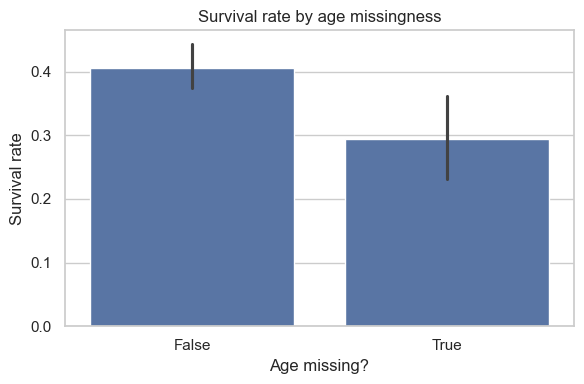

In [17]:
age_missing_summary = df.assign(age_missing=df["age"].isna()).groupby("age_missing").agg(
    passengers=("survived", "size"),
    survival_rate=("survived", "mean"),
    avg_pclass=("pclass", "mean"),
    avg_fare=("fare", "mean")
)
display(age_missing_summary)

contingency = pd.crosstab(df["age"].isna(), df["survived"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

display(contingency)

plt.figure(figsize=(6, 4))
sns.barplot(data=df.assign(age_missing=df["age"].isna()), x="age_missing", y="survived")
plt.title("Survival rate by age missingness")
plt.xlabel("Age missing?")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.show()


### Interpretation guide

Check whether the survival rate differs between passengers with missing and available age. If it differs, a missing indicator may help. The difference may still be explained by other variables such as class, fare, or recording practices.


## Run-specific analytical notes

The comparison table, coefficient plot, error analysis, and missingness checks should be read together. The following cell generates a compact summary from the executed results.

In [18]:

from IPython.display import Markdown, display

def pct_fmt(x):
    return f"{100*x:.2f}%"

best_row = results_df.iloc[0]
simple_row = results_df.loc[results_df["strategy"].eq("simple_imputation_logistic")].iloc[0]
indicator_row = results_df.loc[results_df["strategy"].eq("simple_imputation_with_indicators_logistic")].iloc[0]
drop_row = results_df.loc[results_df["strategy"].eq("drop_missing_rows_logistic")].iloc[0]
rf_row = results_df.loc[results_df["strategy"].eq("simple_imputation_random_forest")].iloc[0]

age_missing_rate = df["age"].isna().mean()
deck_missing_rate = df["deck"].isna().mean()
embarked_missing_rate = df["embarked"].isna().mean()
drop_train_loss = 1 - (len(X_train_drop) / len(X_train))
drop_test_loss = 1 - (len(X_test_drop) / len(X_test))

indicator_delta_f1 = indicator_row["f1"] - simple_row["f1"]
indicator_delta_auc = indicator_row["roc_auc"] - simple_row["roc_auc"]
rf_delta_f1 = rf_row["f1"] - simple_row["f1"]

age_missing_survival = age_missing_summary.loc[True, "survival_rate"] if True in age_missing_summary.index else np.nan
age_available_survival = age_missing_summary.loc[False, "survival_rate"] if False in age_missing_summary.index else np.nan
age_missing_gap = age_missing_survival - age_available_survival

if "error_summary" in globals():
    fn_count = int(error_summary.loc["false_negative", "count"]) if "false_negative" in error_summary.index else 0
    fp_count = int(error_summary.loc["false_positive", "count"]) if "false_positive" in error_summary.index else 0
else:
    fn_count, fp_count = None, None

notes = f"""
### Analytical summary from the executed run

- **Missingness severity:** `deck` has the highest missingness (**{pct_fmt(deck_missing_rate)}**), `age` has moderate missingness (**{pct_fmt(age_missing_rate)}**), and `embarked` has low missingness (**{pct_fmt(embarked_missing_rate)}**). These variables should not be treated with one identical cleaning rule.
- **Dropping rows:** complete-case analysis removes **{pct_fmt(drop_train_loss)}** of the training rows and **{pct_fmt(drop_test_loss)}** of the test rows. This baseline is useful, but it changes the evaluated population.
- **Best strategy by F1-score:** **{best_row['strategy']}** gives the highest F1-score in this single train/test split. This should be interpreted as a practical comparison, not a universal conclusion.
- **Missing indicators:** adding numerical missing indicators changes F1 by **{indicator_delta_f1:+.3f}** and ROC-AUC by **{indicator_delta_auc:+.3f}** relative to simple imputation. A positive value suggests missingness itself helped the classifier; a near-zero or negative value suggests limited added value in this feature set.
- **Model complexity:** the random forest changes F1 by **{rf_delta_f1:+.3f}** relative to simple-imputation logistic regression. If the gain is small, the simpler model may be preferable for explanation.
- **Age missingness as information:** the survival-rate difference between passengers with missing age and available age is **{age_missing_gap:+.3f}**. This is an association, not proof that missing age causes survival differences.
- **Error analysis:** the selected best model produced **{fn_count} false negatives** and **{fp_count} false positives** on the test set used for error analysis. False negatives and false positives should be interpreted differently because they represent different decision failures.
"""

display(Markdown(notes))



### Analytical summary from the executed run

- **Missingness severity:** `deck` has the highest missingness (**77.22%**), `age` has moderate missingness (**19.87%**), and `embarked` has low missingness (**0.22%**). These variables should not be treated with one identical cleaning rule.
- **Dropping rows:** complete-case analysis removes **19.91%** of the training rows and **20.63%** of the test rows. This baseline is useful, but it changes the evaluated population.
- **Best strategy by F1-score:** **drop_missing_rows_logistic** gives the highest F1-score in this single train/test split. This should be interpreted as a practical comparison, not a universal conclusion.
- **Missing indicators:** adding numerical missing indicators changes F1 by **-0.011** and ROC-AUC by **-0.003** relative to simple imputation. A positive value suggests missingness itself helped the classifier; a near-zero or negative value suggests limited added value in this feature set.
- **Model complexity:** the random forest changes F1 by **+0.005** relative to simple-imputation logistic regression. If the gain is small, the simpler model may be preferable for explanation.
- **Age missingness as information:** the survival-rate difference between passengers with missing age and available age is **-0.112**. This is an association, not proof that missing age causes survival differences.
- **Error analysis:** the selected best model produced **17 false negatives** and **20 false positives** on the test set used for error analysis. False negatives and false positives should be interpreted differently because they represent different decision failures.


## Limitations

- The Titanic dataset is small and historically specific.
- The missingness mechanism cannot be proven from observed data alone.
- Some variables are redundant or derived from others.
- Imputation adds assumptions that may not match the true data-generating process.
- A single train/test split can make metric differences unstable.
- Accuracy alone is not enough; precision, recall, F1-score, ROC-AUC, and error types should be compared.
- Better predictive performance does not mean the imputed values are objectively true.


## What we learned

- Missing values are not only technical defects; they can reflect how data was collected.
- Dropping rows is simple, but it may reduce sample size and change the population being modeled.
- Imputation should be fitted inside a train/test pipeline to avoid leakage.
- Missing indicators are useful only when the fact that a value is missing carries predictive information.
- KNN and iterative imputation use more structure from the data, but they are not automatically better than median/mode imputation.
- The best strategy should be chosen by downstream evaluation, error analysis, and interpretability, not by method complexity alone.
- A single train/test split gives a useful first comparison, but stronger conclusions require repeated validation.

## Possible extensions

- Repeat the comparison with cross-validation.
- Simulate MCAR, MAR, and MNAR missingness and compare recovery.
- Use multiple imputation and combine estimates.
- Compare XGBoost, LightGBM, or CatBoost.
- Add calibration analysis for predicted probabilities.
- Study subgroup performance across sex, class, and age groups.
- Build a model card describing data limitations and missing-value assumptions.
